**Paragraph of approach and findings: HEPSIM GSoC 2026 Evaluation — Quark/Gluon Jet Analysis**

In this notebook and test project, I analyze the Pythia 8 quark/gluon jet datasets/files using NumPy, Matplotlib, and scikit-learn. I first loaded and explored the padded constituent-level jet data, computed constituent counts and multiplicity distributions, and then granularly found the leading-constituent kinematics. I then reconstruct massless constituent four-momenta to compute several jet observables, including jet mass, jet width, and $p_T$ dispersion, comparing their distributions for quark and gluon jets. Next, I implemented a Lorentz boost into the jet center-of-mass frame and verified numerically that the total three-momentum vanishes after boosting. Finally, I construct rest-frame geometric features and train a binary classifier to distinguish quark from gluon jets, evaluating its performance with ROC/AUC, a confusion matrix, and univariate feature ranking. Using the QG jet dataset, the analysis shows the expected pattern that gluon jets generally have higher constituent multiplicity and broader radiation patterns than quark jets, which is reflected in distributions such as multiplicity, jet width, and related shape observables. In the classification task, these structural differences provide real discriminating power between quark and gluon jets, with the best performance typically coming from features that capture how diffuse or concentrated the jet is. Future improvement requires engineering rest-frame features that better capture the patterns in classifying quark and gluon jets. 

**Imports and Configuration**

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

**File Paths and Loading**

In [37]:
FILE_PATHS = [
    "/Users/jacobhahn/Desktop/QG_jets.npz",
    "/Users/jacobhahn/Desktop/QG_jets_1.npz",
    "/Users/jacobhahn/Desktop/QG_jets_10.npz",
]
# MAX_FILES is optional but is included in case it is necessary to use 5 files (maximum allowed in test project)
MAX_FILES = 3
RANDOM_STATE = 42
TEST_SIZE = 0.20

In [38]:
#Load files
def load_qg_files(file_paths, max_files=None):
    
    # Load QG jet files and concatenate them. Since different files can have different max padded multiplicities,
    # pad them to the global maximum number of constituents before concatenating.

    # This function returns the following
    
    # X : np.ndarray, shape (N_jets, N_const_max, 4), Constituent features (pT, y, phi, pdgid), zero-padded.
    #y : np.ndarray, shape (N_jets,), Labels: gluon=0, quark=1
    
    selected_paths = file_paths[:max_files] if max_files is not None else file_paths

    X_list = []
    y_list = []

    for path in selected_paths:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Could not find file: {path}")

        data = np.load(path)
        X_i = data["X"]
        y_i = data["y"].astype(np.int8)

        X_list.append(X_i)
        y_list.append(y_i)

        print(f"Loaded {os.path.basename(path)}: X.shape={X_i.shape}, y.shape={y_i.shape}")

    max_constituents = max(arr.shape[1] for arr in X_list)
    print(f"\nGlobal max padded multiplicity across selected files: {max_constituents}")

    X_padded = []
    for arr in X_list:
        n_jets, n_const, n_feat = arr.shape
        if n_const < max_constituents:
            pad_width = max_constituents - n_const
            pad = np.zeros((n_jets, pad_width, n_feat), dtype=arr.dtype)
            arr = np.concatenate([arr, pad], axis=1)
        X_padded.append(arr)

    X = np.concatenate(X_padded, axis=0)
    y = np.concatenate(y_list, axis=0)

    return X, y

In [39]:
X, y = load_qg_files(FILE_PATHS, max_files=MAX_FILES)

print("\nFinal concatenated dataset")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of gluon jets (y=0):", np.sum(y == 0))
print("Number of quark jets (y=1):", np.sum(y == 1))

Loaded QG_jets.npz: X.shape=(100000, 139, 4), y.shape=(100000,)
Loaded QG_jets_1.npz: X.shape=(100000, 134, 4), y.shape=(100000,)
Loaded QG_jets_10.npz: X.shape=(100000, 138, 4), y.shape=(100000,)

Global max padded multiplicity across selected files: 139

Final concatenated dataset
X shape: (300000, 139, 4)
y shape: (300000,)
Number of gluon jets (y=0): 150000
Number of quark jets (y=1): 150000


**BASIC Helper Functions for the following exercises**

In [40]:
# Dataset columns
PT_COL = 0
Y_COL = 1
PHI_COL = 2
PDGID_COL = 3

def valid_constituent_mask(X):
    # Zero-padding is represented by constituents with pT = 0, Returns a boolean mask of shape (N_jets, N_constituents).
    return X[:, :, PT_COL] > 0

def wrap_phi(dphi):
    # Wrap angle differences into [-pi, pi).
    return (dphi + np.pi) % (2 * np.pi) - np.pi

**Part (a): Data loading and exploration**

(i) Total number of constituents across quark and gluon jets

In [41]:
mask = valid_constituent_mask(X)
multiplicity = mask.sum(axis=1)

n_const_gluon = multiplicity[y == 0].sum()
n_const_quark = multiplicity[y == 1].sum()

print("Total number of constituents across gluon jets:", int(n_const_gluon))
print("Total number of constituents across quark jets:", int(n_const_quark))

Total number of constituents across gluon jets: 7974548
Total number of constituents across quark jets: 5004960


(ii) Multiplicity histogram

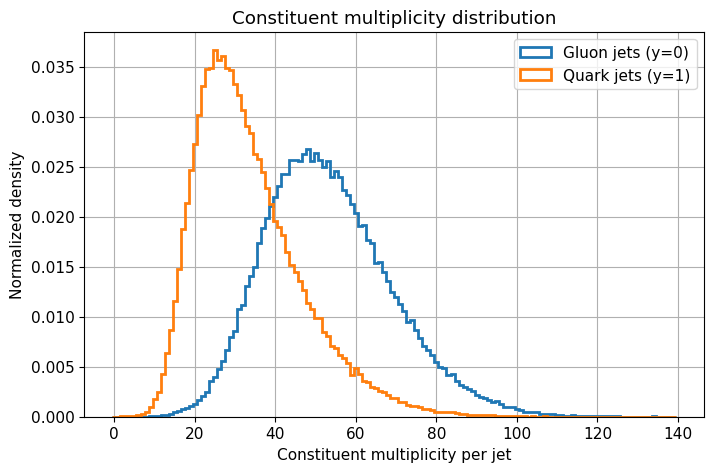

In [42]:
mult_gluon = multiplicity[y == 0]
mult_quark = multiplicity[y == 1]

bins = np.arange(0, multiplicity.max() + 2) - 0.5

plt.figure()
plt.hist(mult_gluon, bins=bins, density=True, histtype="step", linewidth=2, label="Gluon jets (y=0)")
plt.hist(mult_quark, bins=bins, density=True, histtype="step", linewidth=2, label="Quark jets (y=1)")
plt.xlabel("Constituent multiplicity per jet")
plt.ylabel("Normalized density")
plt.title("Constituent multiplicity distribution")
plt.legend()
plt.show()

(iii) Leading-constituent $p_T$ and $y(≈η)$ distributions

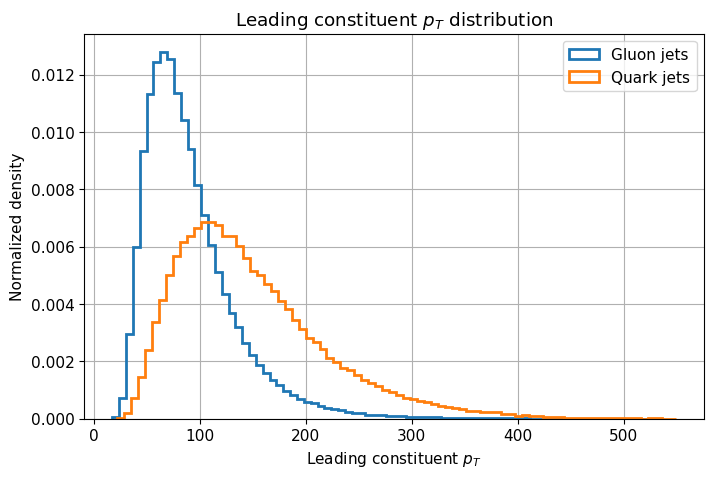

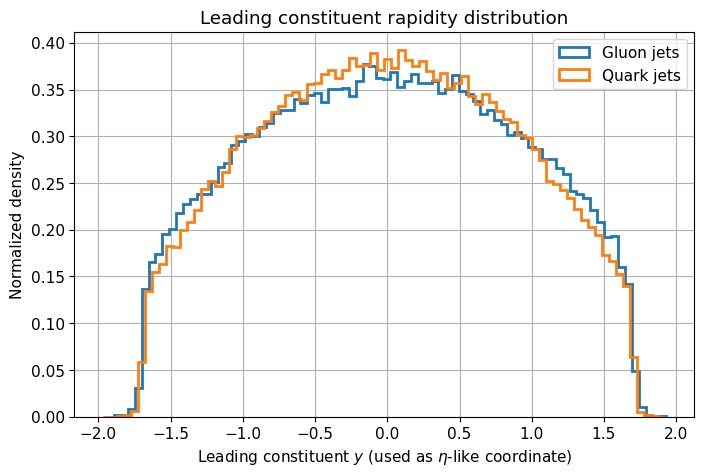

In [43]:
pt = X[:, :, PT_COL]
y_const = X[:, :, Y_COL]

leading_idx = np.argmax(pt, axis=1)
rows = np.arange(X.shape[0])

leading_pt = pt[rows, leading_idx]
leading_y = y_const[rows, leading_idx]

plt.figure()
plt.hist(leading_pt[y == 0], bins=80, density=True, histtype="step", linewidth=2, label="Gluon jets")
plt.hist(leading_pt[y == 1], bins=80, density=True, histtype="step", linewidth=2, label="Quark jets")
plt.xlabel(r"Leading constituent $p_T$")
plt.ylabel("Normalized density")
plt.title(r"Leading constituent $p_T$ distribution")
plt.legend()
plt.show()

plt.figure()
plt.hist(leading_y[y == 0], bins=80, density=True, histtype="step", linewidth=2, label="Gluon jets")
plt.hist(leading_y[y == 1], bins=80, density=True, histtype="step", linewidth=2, label="Quark jets")
plt.xlabel(r"Leading constituent $y$ (used as $\eta$-like coordinate)")
plt.ylabel("Normalized density")
plt.title(r"Leading constituent rapidity distribution")
plt.legend()
plt.show()

**b. Jet Observables**

In [44]:
def constituents_to_massless_p4(X):
    # Reconstruct constituent four-momenta assuming massless constituents.
    # Input columns are (pT, y, phi, pdgid).
    # For massless particles: px = pT cos(phi), py = pT sin(phi), pz = pT sinh(y), E  = pT cosh(y)

    # Returns: E, px, py, pz : arrays of shape (N_jets, N_constituents)

    pt = X[:, :, PT_COL]
    y_ = X[:, :, Y_COL]
    phi = X[:, :, PHI_COL]

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(y_)
    E = pt * np.cosh(y_)

    return E, px, py, pz

In [45]:
def compute_jet_observables(X):
    
    # Compute:, jet mass, jet width, pT dispersion pTD, multiplicity, jet axis eta and phi
    # Returns a dict of 1D arrays.
    
    mask = valid_constituent_mask(X).astype(float)

    pt = X[:, :, PT_COL] * mask
    eta = X[:, :, Y_COL]   # using provided y as eta-like coordinate
    phi = X[:, :, PHI_COL]

    E, px, py, pz = constituents_to_massless_p4(X)
    E *= mask
    px *= mask
    py *= mask
    pz *= mask

    jet_E = E.sum(axis=1)
    jet_px = px.sum(axis=1)
    jet_py = py.sum(axis=1)
    jet_pz = pz.sum(axis=1)

    jet_pt = np.hypot(jet_px, jet_py)
    jet_p = np.sqrt(jet_px**2 + jet_py**2 + jet_pz**2)

    mass2 = np.clip(jet_E**2 - jet_p**2, 0.0, None)
    jet_mass = np.sqrt(mass2)

    jet_eta = np.arcsinh(
        np.divide(jet_pz, jet_pt, out=np.zeros_like(jet_pz), where=jet_pt > 0)
    )
    jet_phi = np.arctan2(jet_py, jet_px)

    d_eta = eta - jet_eta[:, None]
    d_phi = wrap_phi(phi - jet_phi[:, None])
    dR = np.sqrt(d_eta**2 + d_phi**2) * mask

    pt_sum = pt.sum(axis=1)

    jet_width = np.divide(
        (pt * dR).sum(axis=1),
        pt_sum,
        out=np.zeros(X.shape[0]),
        where=pt_sum > 0
    )

    ptd = np.divide(
        np.sqrt((pt**2).sum(axis=1)),
        pt_sum,
        out=np.zeros(X.shape[0]),
        where=pt_sum > 0
    )

    multiplicity = mask.sum(axis=1).astype(int)

    return {
        "mass": jet_mass,
        "width": jet_width,
        "ptd": ptd,
        "multiplicity": multiplicity,
        "jet_eta": jet_eta,
        "jet_phi": jet_phi,
        "jet_E": jet_E,
        "jet_px": jet_px,
        "jet_py": jet_py,
        "jet_pz": jet_pz,
    }

In [46]:
obs_lab = compute_jet_observables(X)

for key in ["mass", "width", "ptd", "multiplicity"]:
    print(key, obs_lab[key][:5])

mass [16.10836617 17.079508   71.89869727 57.22178244 19.92763258]
width [0.00994297 0.00987708 0.11247712 0.06995403 0.01367899]
ptd [0.6824877  0.504385   0.24897114 0.31085092 0.42224097]
multiplicity [18 17 57 37 35]


**Plotting the lab-frame observables**

In [47]:
def plot_two_class_hist(values, labels, xlabel, title, bins=80, density=True, logy=False):
    plt.figure()
    plt.hist(values[labels == 0], bins=bins, density=density, histtype="step", linewidth=2, label="Gluon jets")
    plt.hist(values[labels == 1], bins=bins, density=density, histtype="step", linewidth=2, label="Quark jets")
    plt.xlabel(xlabel)
    plt.ylabel("Normalized density" if density else "Count")
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.show()

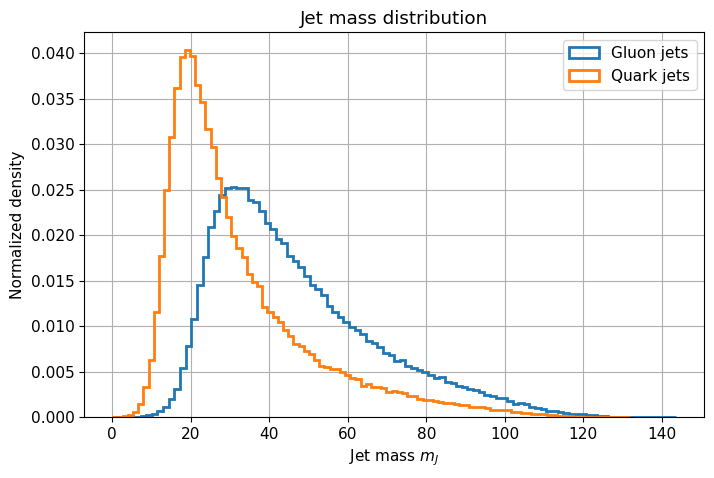

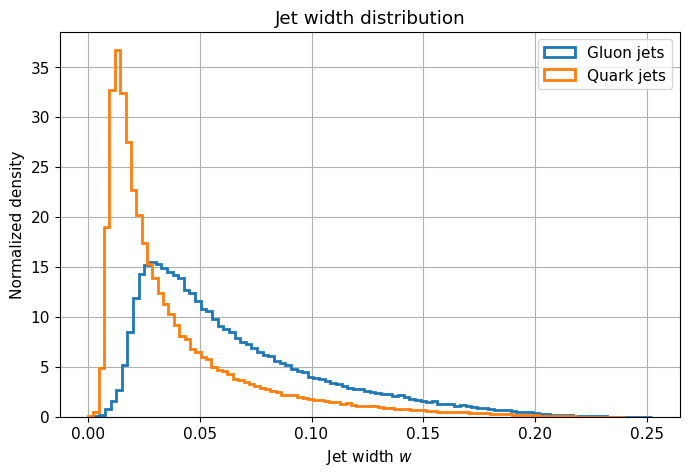

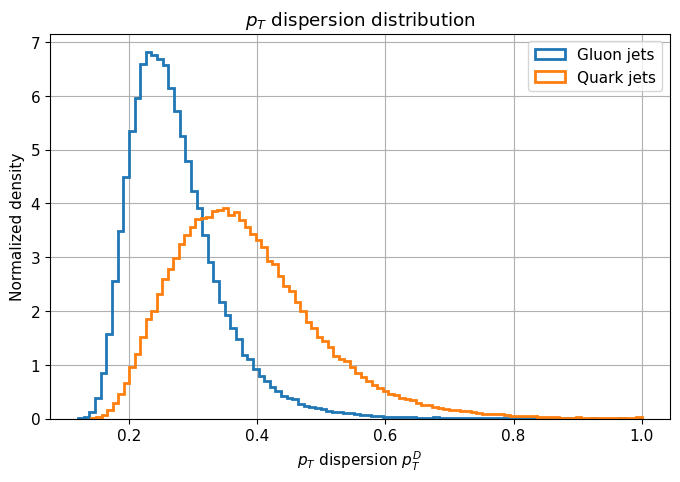

In [48]:
plot_two_class_hist(
    obs_lab["mass"],
    y,
    xlabel=r"Jet mass $m_J$",
    title="Jet mass distribution",
    bins=100
)

plot_two_class_hist(
    obs_lab["width"],
    y,
    xlabel=r"Jet width $w$",
    title="Jet width distribution",
    bins=100
)

plot_two_class_hist(
    obs_lab["ptd"],
    y,
    xlabel=r"$p_T$ dispersion $p_T^D$",
    title=r"$p_T$ dispersion distribution",
    bins=100
)

**c. Boost to the Jet Center-of-Mass Frame**

(i) Boost implementation

In [49]:
def lorentz_boost_batch(E, px, py, pz, beta):
    # Apply a Lorentz boost with velocity vector beta to a batch of constituent four-vectors.

    # Parameters: E, px, py, pz : arrays, shape (N_jets, N_constituents), beta : array, shape (N_jets, 3)

    #Returns: E_prime, px_prime, py_prime, pz_prime : arrays, shape (N_jets, N_constituents)

    # Formula: E' = gamma (E - beta · p), p' = p + ((gamma - 1)/(beta^2)) (beta · p) beta - gamma E beta

    # To go to the jet rest frame, use beta = p_jet / E_jet.
    
    p = np.stack([px, py, pz], axis=-1)   # (N_jets, N_const, 3)

    beta2 = np.sum(beta**2, axis=1)       # (N_jets,)
    gamma = 1.0 / np.sqrt(np.clip(1.0 - beta2, 1e-15, None))

    beta_dot_p = np.sum(p * beta[:, None, :], axis=-1)  # (N_jets, N_const)

    factor = np.divide(
        (gamma[:, None] - 1.0) * beta_dot_p,
        beta2[:, None],
        out=np.zeros_like(beta_dot_p),
        where=beta2[:, None] > 0
    )

    p_prime = (
        p
        + factor[..., None] * beta[:, None, :]
        - gamma[:, None, None] * E[..., None] * beta[:, None, :]
    )

    E_prime = gamma[:, None] * (E - beta_dot_p)

    return E_prime, p_prime[:, :, 0], p_prime[:, :, 1], p_prime[:, :, 2]

In [50]:
def boost_jets_to_rest_frame(X):

    # Boost all constituents in each jet to the frame where the jet three-momentum vanishes.
    # Returns: E_rest, px_rest, py_rest, pz_rest : arrays, shape (N_jets, N_constituents), beta : array, shape (N_jets, 3)

    # The boost vector is: beta = p_jet / E_jet
    
    mask = valid_constituent_mask(X).astype(float)

    E, px, py, pz = constituents_to_massless_p4(X)
    E *= mask
    px *= mask
    py *= mask
    pz *= mask

    jet_E = E.sum(axis=1)
    jet_p = np.stack([px.sum(axis=1), py.sum(axis=1), pz.sum(axis=1)], axis=1)

    beta = np.divide(
        jet_p,
        jet_E[:, None],
        out=np.zeros_like(jet_p),
        where=jet_E[:, None] > 0
    )

    E_rest, px_rest, py_rest, pz_rest = lorentz_boost_batch(E, px, py, pz, beta)

    return E_rest, px_rest, py_rest, pz_rest, beta

**(ii) Verify your implementation by showing that the total three-momentum of the boosted constituents vanishes** 

In [51]:
E_rest, px_rest, py_rest, pz_rest, beta = boost_jets_to_rest_frame(X)

p_rest_total = np.stack(
    [px_rest.sum(axis=1), py_rest.sum(axis=1), pz_rest.sum(axis=1)],
    axis=1
)

p_rest_norm = np.linalg.norm(p_rest_total, axis=1)

print("Max |sum p_rest| over all jets:", np.max(p_rest_norm))
print("Mean |sum p_rest| over all jets:", np.mean(p_rest_norm))
print("Median |sum p_rest| over all jets:", np.median(p_rest_norm))

Max |sum p_rest| over all jets: 1.9073486328125e-06
Mean |sum p_rest| over all jets: 1.481534266945965e-11
Median |sum p_rest| over all jets: 1.1619670870588394e-12


**(iii) Example rest-frame scatter plots**

In [52]:
def plot_rest_frame_jet_examples(X, y, n_each=1, seed=42):
    # Plot a few quark and gluon jets in the jet rest frame in the (px, py) plane.
    # Point size is proportional to constituent energy.
    
    rng = np.random.default_rng(seed)

    gluon_idx = np.where(y == 0)[0]
    quark_idx = np.where(y == 1)[0]

    chosen_gluon = rng.choice(gluon_idx, size=n_each, replace=False)
    chosen_quark = rng.choice(quark_idx, size=n_each, replace=False)

    chosen = np.concatenate([chosen_gluon, chosen_quark])

    E_r, px_r, py_r, pz_r, _ = boost_jets_to_rest_frame(X[chosen])
    mask = valid_constituent_mask(X[chosen])

    ncols = len(chosen)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), squeeze=False)
    axes = axes[0]

    for ax, local_i, global_i in zip(axes, range(len(chosen)), chosen):
        m = mask[local_i]
        e = E_r[local_i, m]
        px = px_r[local_i, m]
        py = py_r[local_i, m]

        sizes = 20 + 200 * e / e.max()

        label = "Gluon jet" if y[global_i] == 0 else "Quark jet"
        ax.scatter(px, py, s=sizes, alpha=0.7)
        ax.axhline(0, color="black", linewidth=1)
        ax.axvline(0, color="black", linewidth=1)
        ax.set_xlabel(r"$p_x^{\rm rest}$")
        ax.set_ylabel(r"$p_y^{\rm rest}$")
        ax.set_title(f"{label}\njet index = {global_i}")
        ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

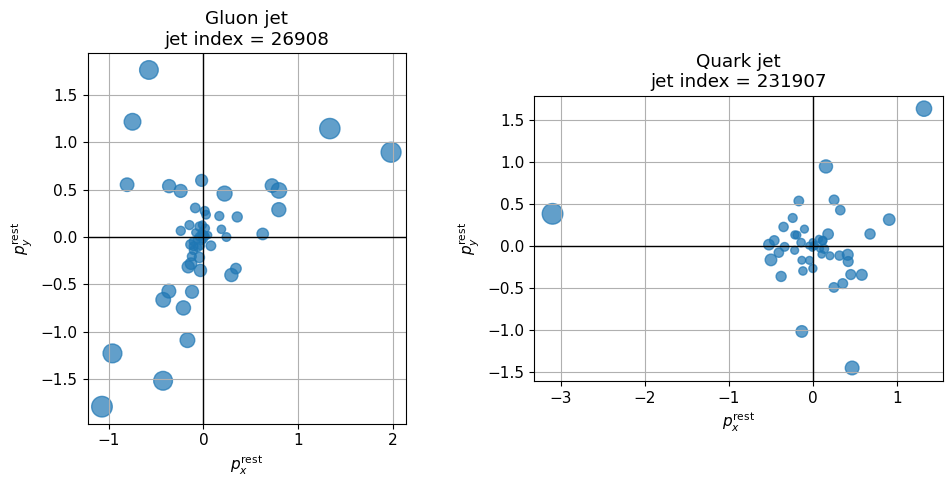

In [53]:
plot_rest_frame_jet_examples(X, y, n_each=1, seed=RANDOM_STATE)

In the jet rest frame, quark jets often appear somewhat more concentrated, while gluon jets tend to show broader and more diffuse constituent momentum patterns, consistent with their larger color factor and higher average multiplicity. The exact visual impression varies from jet to jet, but gluon jets generally look busier in this case (even though the quark jet appears to have an outlier).

**(d): Rest-frame feature engineering**

In [54]:
def compute_rest_frame_features(X):
    # Compute a set of rest-frame geometric features for each jet.

    mask = valid_constituent_mask(X).astype(float)

    E_r, px_r, py_r, pz_r, _ = boost_jets_to_rest_frame(X)
    p_r = np.stack([px_r, py_r, pz_r], axis=-1)
    p_mag = np.linalg.norm(p_r, axis=-1)

    E_sum = E_r.sum(axis=1)
    mult = mask.sum(axis=1).astype(float)

    # Leading constituent in rest frame by energy
    lead_idx = np.argmax(E_r, axis=1)
    rows = np.arange(X.shape[0])

    lead_vec = p_r[rows, lead_idx, :]
    lead_norm = np.linalg.norm(lead_vec, axis=1)

    dots = np.sum(p_r * lead_vec[:, None, :], axis=-1)

    cos_theta = np.divide(
        dots,
        p_mag * lead_norm[:, None],
        out=np.ones_like(dots),
        where=(p_mag > 0) & (lead_norm[:, None] > 0)
    )
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta) * mask

    ang_width_rest = np.divide(
        (E_r * theta).sum(axis=1),
        E_sum,
        out=np.zeros(X.shape[0]),
        where=E_sum > 0
    )

    energy_disp_rest = np.divide(
        np.sqrt((E_r**2).sum(axis=1)),
        E_sum,
        out=np.zeros(X.shape[0]),
        where=E_sum > 0
    )

    lead_E_frac_rest = np.divide(
        E_r.max(axis=1),
        E_sum,
        out=np.zeros(X.shape[0]),
        where=E_sum > 0
    )

    # Momentum tensor for event-shape features
    denom = (p_mag**2).sum(axis=1)
    M = np.zeros((X.shape[0], 3, 3))

    for a in range(3):
        for b in range(3):
            M[:, a, b] = (p_r[:, :, a] * p_r[:, :, b]).sum(axis=1)

    M = np.divide(
        M,
        denom[:, None, None],
        out=np.zeros_like(M),
        where=denom[:, None, None] > 0
    )

    eigvals = np.linalg.eigvalsh(M)
    eigvals = np.sort(eigvals, axis=1)[:, ::-1]  # lambda1 >= lambda2 >= lambda3

    lam1 = eigvals[:, 0]
    lam2 = eigvals[:, 1]
    lam3 = eigvals[:, 2]

    sphericity_rest = 1.5 * (lam2 + lam3)
    aplanarity_rest = 1.5 * lam3
    planarity_rest = lam2 - lam3

    features = {
        "mult_rest": mult,
        "lead_E_frac_rest": lead_E_frac_rest,
        "ang_width_rest": ang_width_rest,
        "energy_disp_rest": energy_disp_rest,
        "sphericity_rest": sphericity_rest,
        "aplanarity_rest": aplanarity_rest,
        "planarity_rest": planarity_rest,
    }

    return features

In [55]:
rest_features = compute_rest_frame_features(X)

feature_names = list(rest_features.keys())
X_rest_features = np.column_stack([rest_features[name] for name in feature_names])

print("Rest-frame feature matrix shape:", X_rest_features.shape)
print("Feature names:", feature_names)

Rest-frame feature matrix shape: (300000, 7)
Feature names: ['mult_rest', 'lead_E_frac_rest', 'ang_width_rest', 'energy_disp_rest', 'sphericity_rest', 'aplanarity_rest', 'planarity_rest']


Baseline lab-frame features for comparison:

In [56]:
X_lab_features = np.column_stack([
    obs_lab["multiplicity"].astype(float),
    obs_lab["mass"],
    obs_lab["width"],
    obs_lab["ptd"],
])

lab_feature_names = ["multiplicity", "mass", "width", "ptd"]

print("Lab-frame baseline feature matrix shape:", X_lab_features.shape)

Lab-frame baseline feature matrix shape: (300000, 4)


Train/test split. Use the same split for lab-frame and rest-frame comparisons.

In [57]:
indices = np.arange(len(y))

idx_train, idx_test = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_rest = X_rest_features[idx_train]
X_test_rest = X_rest_features[idx_test]

X_train_lab = X_lab_features[idx_train]
X_test_lab = X_lab_features[idx_test]

y_train = y[idx_train]
y_test = y[idx_test]

print("Training jets:", len(idx_train))
print("Test jets:", len(idx_test))

Training jets: 240000
Test jets: 60000


Train the rest-frame classifier. Used HistGradientBoostingClassifier because it handles nonlinear structure well and trains faster than many alternatives on tabular data.

In [58]:
clf_rest = HistGradientBoostingClassifier(
    max_depth=4,
    learning_rate=0.05,
    max_iter=200,
    min_samples_leaf=50,
    random_state=RANDOM_STATE
)

clf_rest.fit(X_train_rest, y_train)

y_score_rest = clf_rest.predict_proba(X_test_rest)[:, 1]
y_pred_rest = (y_score_rest >= 0.5).astype(int)

auc_rest = roc_auc_score(y_test, y_score_rest)
print("Rest-frame AUC:", auc_rest)

Rest-frame AUC: 0.8648686916666666


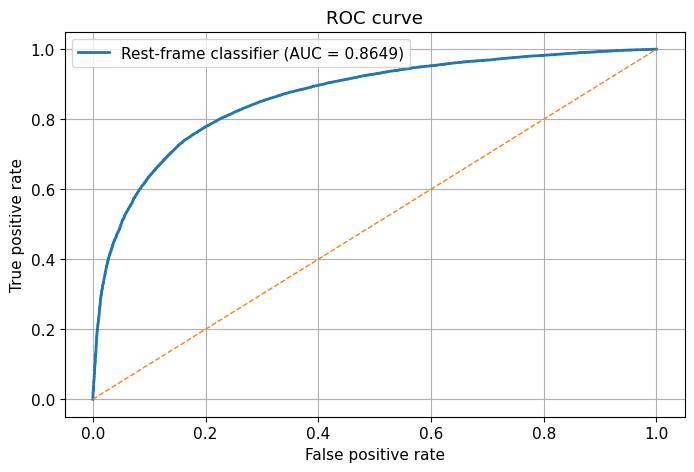

In [59]:
fpr_rest, tpr_rest, thr_rest = roc_curve(y_test, y_score_rest)

plt.figure()
plt.plot(fpr_rest, tpr_rest, linewidth=2, label=f"Rest-frame classifier (AUC = {auc_rest:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

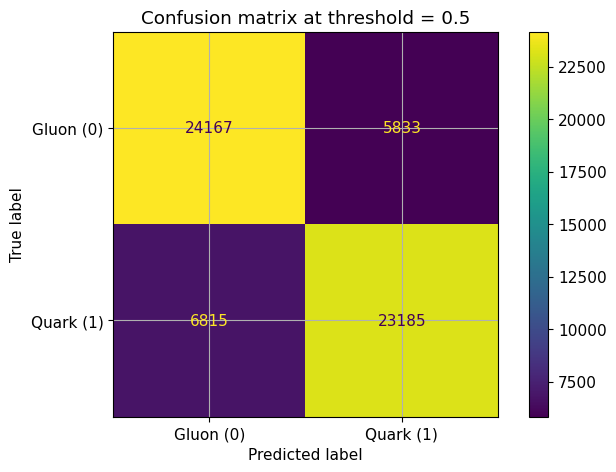

In [60]:
cm_rest = confusion_matrix(y_test, y_pred_rest)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rest, display_labels=["Gluon (0)", "Quark (1)"])
disp.plot(values_format="d")
plt.title("Confusion matrix at threshold = 0.5")
plt.show()

Single most discriminating feature: A clean way to report this is to compute the test-set AUC for each feature individually

In [61]:
def best_univariate_auc(X_features, y_true, feature_names):
    # For each individual feature, compute the best AUC obtainable by using either the raw feature or its negative as a score.
    results = []

    for i, name in enumerate(feature_names):
        score = X_features[:, i]

        auc_pos = roc_auc_score(y_true, score)
        auc_neg = roc_auc_score(y_true, -score)

        if auc_pos >= auc_neg:
            best_auc = auc_pos
            direction = "higher values -> more quark-like"
        else:
            best_auc = auc_neg
            direction = "lower values -> more quark-like"

        results.append((name, best_auc, direction))

    results.sort(key=lambda x: x[1], reverse=True)
    return results

In [62]:
univariate_results = best_univariate_auc(X_test_rest, y_test, feature_names)

print("Univariate feature ranking by AUC:")
for name, auc_val, direction in univariate_results:
    print(f"{name:20s}  AUC = {auc_val:.4f}   ({direction})")

best_feature_name, best_feature_auc, best_feature_direction = univariate_results[0]

print("\nSingle most discriminating rest-frame feature:")
print("Feature:", best_feature_name)
print("AUC:", round(best_feature_auc, 4))
print("Interpretation:", best_feature_direction)

Univariate feature ranking by AUC:
mult_rest             AUC = 0.8410   (lower values -> more quark-like)
energy_disp_rest      AUC = 0.8282   (higher values -> more quark-like)
lead_E_frac_rest      AUC = 0.7724   (higher values -> more quark-like)
aplanarity_rest       AUC = 0.6915   (lower values -> more quark-like)
sphericity_rest       AUC = 0.6899   (lower values -> more quark-like)
planarity_rest        AUC = 0.6331   (lower values -> more quark-like)
ang_width_rest        AUC = 0.5513   (lower values -> more quark-like)

Single most discriminating rest-frame feature:
Feature: mult_rest
AUC: 0.841
Interpretation: lower values -> more quark-like


**Compare rest-frame vs lab-frame features**

In [63]:
clf_lab = HistGradientBoostingClassifier(
    max_depth=4,
    learning_rate=0.05,
    max_iter=200,
    min_samples_leaf=50,
    random_state=RANDOM_STATE
)

clf_lab.fit(X_train_lab, y_train)
y_score_lab = clf_lab.predict_proba(X_test_lab)[:, 1]
auc_lab = roc_auc_score(y_test, y_score_lab)

print("Lab-frame baseline AUC:", auc_lab)
print("Rest-frame feature AUC:", auc_rest)

Lab-frame baseline AUC: 0.8645727649999999
Rest-frame feature AUC: 0.8648686916666666


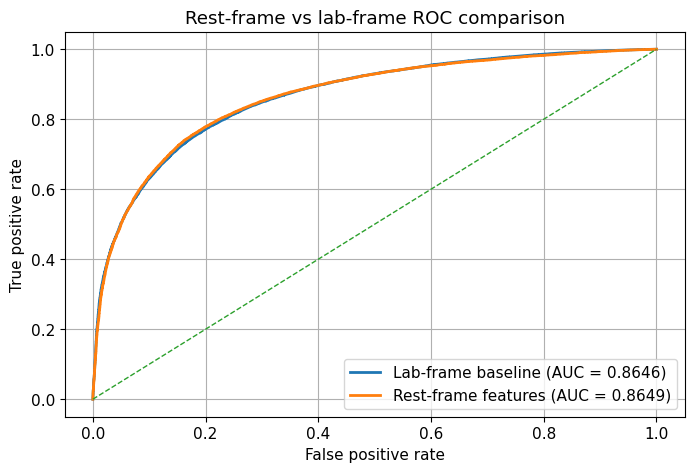

In [64]:
fpr_lab, tpr_lab, _ = roc_curve(y_test, y_score_lab)

plt.figure()
plt.plot(fpr_lab, tpr_lab, linewidth=2, label=f"Lab-frame baseline (AUC = {auc_lab:.4f})")
plt.plot(fpr_rest, tpr_rest, linewidth=2, label=f"Rest-frame features (AUC = {auc_rest:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Rest-frame vs lab-frame ROC comparison")
plt.legend()
plt.show()

Compared with a simple lab-frame baseline built from multiplicity, mass, width, and $p_T$, the rest-frame feature set made little difference. This suggests that the chosen rest-frame features were not sufficiently informative, and that other features could be engineered in future testing to enhance ROC-AUC.

**SUMMARY**

In [65]:
print(f"Total jets used: {len(y)}")
print(f"Gluon jets: {np.sum(y == 0)}")
print(f"Quark jets: {np.sum(y == 1)}")
print(f"Total constituents in gluon jets: {int(n_const_gluon)}")
print(f"Total constituents in quark jets: {int(n_const_quark)}")
print(f"Rest-frame AUC: {auc_rest:.4f}")
print(f"Lab-frame baseline AUC: {auc_lab:.4f}")
print(f"Best single rest-frame feature: {best_feature_name} (AUC = {best_feature_auc:.4f})")

Total jets used: 300000
Gluon jets: 150000
Quark jets: 150000
Total constituents in gluon jets: 7974548
Total constituents in quark jets: 5004960
Rest-frame AUC: 0.8649
Lab-frame baseline AUC: 0.8646
Best single rest-frame feature: mult_rest (AUC = 0.8410)
